In [2]:
import sys
print(sys.executable)

c:\Users\hp\OneDrive\Desktop\email_spam_detection\.venv\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries working!")
print("Pandas:", pd.__version__)

All libraries working!
Pandas: 3.0.6


In [4]:
import os

print(os.getcwd())

c:\Users\hp\OneDrive\Desktop\email_spam_detection\Notebook


In [5]:
import pandas as pd

df = pd.read_csv("../data/raw/spam.csv", encoding="latin-1")

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
print(df.shape)
print(df.columns)

(5572, 2)
Index(['Category', 'Message'], dtype='str')


In [7]:
df.columns

Index(['Category', 'Message'], dtype='str')

In [8]:
df.shape

(5572, 2)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5572 non-null   str  
 1   Message   5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [10]:
df = df.rename(columns={
    "v1": "label",
    "v2": "message"
})

In [11]:


print(df.columns.tolist())

['Category', 'Message']


In [12]:
print(df.head())

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [13]:
df = df.rename(columns={
    "Category": "label",
    "Message": "message"
})

In [14]:
print(df.columns.tolist())

['label', 'message']


In [15]:
df = df[["label", "message"]]

In [16]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [18]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 415


In [19]:
df = df.drop_duplicates()

In [20]:
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (5157, 2)


In [21]:
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

In [22]:
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [23]:
df["label"].value_counts()

label
ham     4516
spam     641
Name: count, dtype: int64

In [24]:
df.shape
df["label"].value_counts()

label
ham     4516
spam     641
Name: count, dtype: int64

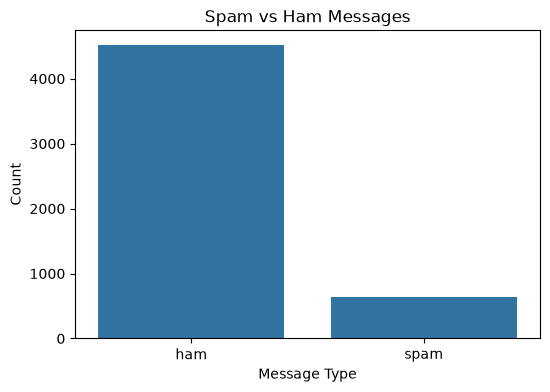

In [25]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="label")

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

In [26]:
label_percentage = df["label"].value_counts(normalize=True) * 100

print(label_percentage)

label
ham     87.570293
spam    12.429707
Name: proportion, dtype: float64


In [27]:
df["message_length"] = df["message"].apply(len)

In [28]:
df[["label", "message", "message_length"]].head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [29]:
df.groupby("label")["message_length"].mean()

label
ham      70.951063
spam    137.541342
Name: message_length, dtype: float64

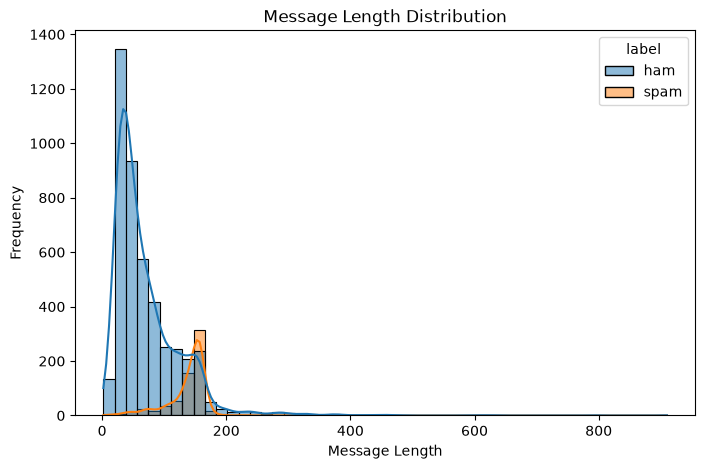

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.show()

In [31]:
df[df["label"] == "spam"]["message"].head(10).tolist()

["Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's",
 "FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, Â£1.50 to rcv",
 'WINNER!! As a valued network customer you have been selected to receivea Â£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.',
 'Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030',
 'SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 4 info',
 'URGENT! You have won a 1 week FREE membership in our Â£100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net LCCLTD POBOX 4403LDNW1A7RW18',
 'XXXMobileMovieClub: To use your credit, click the WAP link in

In [32]:
df[df["label"] == "ham"]["message"].head(10).tolist()

['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...',
 'Ok lar... Joking wif u oni...',
 'U dun say so early hor... U c already then say...',
 "Nah I don't think he goes to usf, he lives around here though",
 'Even my brother is not like to speak with me. They treat me like aids patent.',
 "As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune",
 "I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.",
 "I've been searching for the right words to thank you for this breather. I promise i wont take your help for granted and will fulfil my promise. You have been wonderful and a blessing at all times.",
 'I HAVE A DATE ON SUNDAY WITH WILL!!',
 "Oh k...i'm watching here:)"]

In [33]:
df.head()

,label,message,label_num,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",0,111
1,ham,Ok lar... Joking wif u oni...,0,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155
3,ham,U dun say so early hor... U c already then say...,0,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61


In [34]:
import re
import nltk

In [35]:
nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [36]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [37]:

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Stemming
    words = [stemmer.stem(word) for word in words]

    # Join words back
    return " ".join(words)

In [38]:
sample = "WIN a FREE prize!!! Click here NOW!!!"

print("Original:")
print(sample)

print("\nProcessed:")
print(preprocess_text(sample))

Original:
WIN a FREE prize!!! Click here NOW!!!

Processed:
win free prize click


In [39]:
df["clean_message"] = df["message"].apply(preprocess_text)

In [40]:
df[["message", "clean_message"]].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl week word back id like fun st...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request mell mell oru minnaminungint nurun...
8,WINNER!! As a valued network customer you have...,winner valu network custom select receivea pri...
9,Had your mobile 11 months or more? U R entitle...,mobil month u r entitl updat latest colour mob...


In [41]:
print("Empty cleaned messages:",
      (df["clean_message"].str.strip() == "").sum())

Empty cleaned messages: 6


In [42]:
df[df["clean_message"].str.strip() == ""][["label", "message"]]

,label,message
960,ham,Where @
1612,ham,645
2807,ham,Can a not?
3376,ham,:)
4575,ham,:( but your not here....
4824,ham,:-) :-)


In [43]:

df = df[df["clean_message"].str.strip() != ""].copy()

In [44]:
print("Empty cleaned messages:",
      (df["clean_message"].str.strip() == "").sum())

Empty cleaned messages: 0


In [45]:
from sklearn.model_selection import train_test_split

X = df["clean_message"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [46]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4120
Testing samples: 1031


In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

In [48]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [49]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4120, 5000)
Testing TF-IDF shape: (1031, 5000)


In [50]:
print(vectorizer.get_feature_names_out()[:30])

['abi' 'abiola' 'abl' 'abl come' 'abl deliv' 'abl get' 'abt' 'ac' 'acc'
 'accept' 'access' 'accid' 'accident' 'account' 'account statement' 'ach'
 'across' 'across sea' 'act' 'action' 'activ' 'actual' 'ad' 'add'
 'address' 'admir' 'admir look' 'ador' 'adult' 'advanc']


In [51]:
X_train_tfidf.shape
X_test_tfidf.shape

(1031, 5000)

In [52]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [53]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3607., 513.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.08]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 5000)","[[1.39,2.54,7.34,...,1.61,1.34,0. ], [0. ,0. ,0. ,...,0. ,0. ,0.66]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 5000)","[[-8.69,-8.3 ,-7.44,...,-8.6 ,-8.71,-9.56], [-8.86,-8.86,-8.86,...,-8.86,-8.86,-8.35]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


In [54]:
nb_pred = nb_model.predict(X_test_tfidf)

print(nb_pred[:20])

[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]


In [55]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [56]:
lr_pred = lr_model.predict(X_test_tfidf)

print(lr_pred[:20])

[0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0]


In [57]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [58]:
svm_pred = svm_model.predict(X_test_tfidf)

print(svm_pred[:20])

[0 0 0 0 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0]


In [59]:
from sklearn.metrics import accuracy_score

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Linear SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

Naive Bayes Accuracy: 0.9699321047526673
Logistic Regression Accuracy: 0.9670223084384093
Linear SVM Accuracy: 0.9864209505334627


In [62]:
from sklearn.metrics import classification_report

print("===== Naive Bayes =====")
print(classification_report(
    y_test,
    nb_pred,
    target_names=["Ham", "Spam"]
))

print("===== Logistic Regression =====")
print(classification_report(
    y_test,
    lr_pred,
    target_names=["Ham", "Spam"]
))

print("===== Linear SVM =====")
print(classification_report(
    y_test,
    svm_pred,
    target_names=["Ham", "Spam"]
))

===== Naive Bayes =====
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       903
        Spam       0.99      0.77      0.86       128

    accuracy                           0.97      1031
   macro avg       0.98      0.88      0.92      1031
weighted avg       0.97      0.97      0.97      1031

===== Logistic Regression =====
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.74      0.85       128

    accuracy                           0.97      1031
   macro avg       0.98      0.87      0.91      1031
weighted avg       0.97      0.97      0.96      1031

===== Linear SVM =====
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       903
        Spam       0.97      0.92      0.94       128

    accuracy                           0.99      1031
   macro avg       0.98      0.96      0.97      

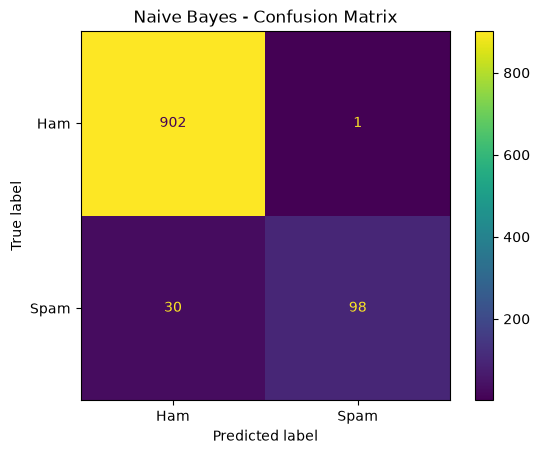

In [63]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, nb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Naive Bayes - Confusion Matrix")
plt.show()

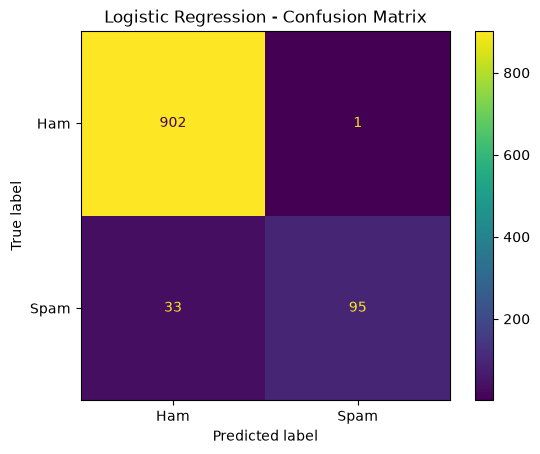

In [64]:
cm_lr = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

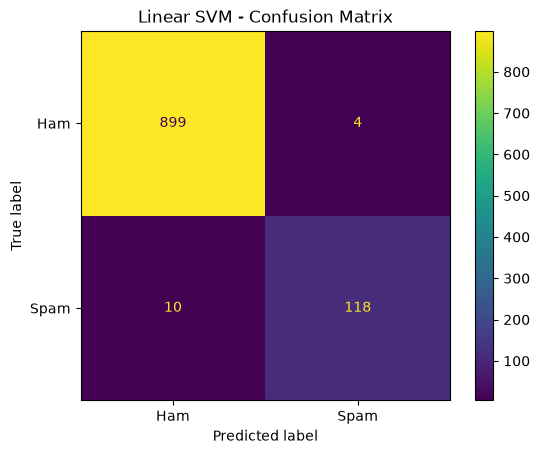

In [65]:
cm_svm = confusion_matrix(y_test, svm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Linear SVM - Confusion Matrix")
plt.show()

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

models = {
    "Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "Linear SVM": svm_pred
}

for model_name, predictions in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.969932,0.989899,0.765625,0.863436
1,Logistic Regression,0.967022,0.989583,0.742188,0.848214
2,Linear SVM,0.986421,0.967213,0.921875,0.944000


In [67]:

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.969932,0.989899,0.765625,0.863436
1,Logistic Regression,0.967022,0.989583,0.742188,0.848214
2,Linear SVM,0.986421,0.967213,0.921875,0.944000


In [68]:
import joblib

joblib.dump(lr_model, "../models/spam_model.pkl")
joblib.dump(vectorizer, "../models/vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
